In [5]:
import pandas as pd

# 1. Load data dari file Excel yang sebelumnya dibuat (sebagai data baru)
df = pd.read_excel('cleaned_scopus_data.xlsx')

# 2. Daftar kolom yang akan dihapus
# (Nama kolom disesuaikan dengan format standar yang sudah dilakukan sebelumnya: huruf kecil & underscore)
cols_to_drop = [
    'author_full_names', 
    'authors_id', 
    'volume', 
    'issue', 
    'art_no', 
    'page_start', 
    'page_end', 
    'abbreviated_source_title'
]

# 3. Hapus kolom jika ada di dataframe
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# 4. Tampilkan Info dan Head untuk memastikan kolom sudah terhapus
print("Info Dataframe setelah penghapusan kolom:")
print(df.info())

print("\nContoh 5 baris pertama data:")
print(df.head())

Info Dataframe setelah penghapusan kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18613 entries, 0 to 18612
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   authors          17717 non-null  object
 1   title            18613 non-null  object
 2   year             18613 non-null  int64 
 3   source_title     13021 non-null  object
 4   link             18613 non-null  object
 5   abstract         18613 non-null  object
 6   author_keywords  14653 non-null  object
 7   index_keywords   12579 non-null  object
 8   publisher        17315 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.3+ MB
None

Contoh 5 baris pertama data:
                                             authors  \
0                   Shinyclimensa, C.; Parthiban, A.   
1                                    Shashikumar, N.   
2  Budhathoki, M.; Li, L.; Xu, H.; Zhang, W.; Ma,...   
3       Ullah, Q.; Qiu, Y.; Khan Kakar, S.; Sa

In [2]:
df.head().dropna(inplace=True)

C:\Users\TUF\AppData\Local\Temp\ipykernel_36516\3903597352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.head().dropna(inplace=True)


In [6]:
# 3. Filter Tahun (Hanya simpan 2015 <= Tahun <= 2025)
df = df[(df['year'] >= 2015) & (df['year'] <= 2025)]

# Tampilkan Informasi Data Hasil Filter
print(f"Data tersisa: {len(df)} baris")
print("Tahun Min:", df['year'].min())
print("Tahun Max:", df['year'].max())
print(df.head())

Data tersisa: 16182 baris
Tahun Min: 2015
Tahun Max: 2025
                                               authors  \
396                        Wang, H.; Wang, L.; Zhu, F.   
397                               Pham, H.B.; Briš, P.   
398  Luo, H.; Akkermans, S.; Engels, W.; Jacobs, S....   
399                  Giri, P.; Debnath, B.K.; Paul, S.   
400                                  Lai, Y.; Yuan, Y.   

                                                 title  year  \
396  Enhancing Renewable Energy Forecasting Through...  2025   
397  AI in Supply Chain: Techniques, Applications, ...  2025   
398  Hybrid plant-dairy cheese: Effects of lactic a...  2025   
399  A hybrid fuzzy decision-making framework for m...  2025   
400  Comparative Analysis of BSS, PTO, and E2E Stra...  2025   

                                          source_title  \
396  International Journal of Renewable Energy Rese...   
397             Operations and Supply Chain Management   
398                               

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16182 entries, 396 to 16577
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   authors          15475 non-null  object
 1   title            16182 non-null  object
 2   year             16182 non-null  int64 
 3   source_title     11331 non-null  object
 4   link             16182 non-null  object
 5   abstract         16182 non-null  object
 6   author_keywords  13169 non-null  object
 7   index_keywords   10518 non-null  object
 8   publisher        16147 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.2+ MB


In [8]:
df = df.drop_duplicates(subset=['title', 'abstract'], keep='first')

# Cek hasil
print(f"Jumlah data setelah hapus duplikat Title & Abstract: {len(df)}")

Jumlah data setelah hapus duplikat Title & Abstract: 16179


In [9]:
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6286 entries, 396 to 16574
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   authors          6286 non-null   object
 1   title            6286 non-null   object
 2   year             6286 non-null   int64 
 3   source_title     6286 non-null   object
 4   link             6286 non-null   object
 5   abstract         6286 non-null   object
 6   author_keywords  6286 non-null   object
 7   index_keywords   6286 non-null   object
 8   publisher        6286 non-null   object
dtypes: int64(1), object(8)
memory usage: 491.1+ KB


In [14]:
import pandas as pd
import re

pd.set_option('display.max_colwidth', None)

# --- FUNGSI 1: CLEANING DULU (Regex) ---
def step_cleaning_first(text):
    text = str(text)
    # 1. Hapus Tag HTML (misal: <inf>, <sub>)
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 2. Hapus Metadata Copyright (dari © sampai akhir string)
    text = re.sub(r'©.*$', '', text)
    
    # 3. Hapus Angka & Simbol (Hanya sisakan Huruf dan Spasi)
    # Regex: Hapus karakter yg BUKAN (^) a-z, A-Z, atau spasi
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 4. Hapus huruf tunggal yang berdiri sendiri (opsional, mengurangi noise 'x', 'y')
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)
    # PERHATIKAN: Regex ditambah 'A-Z' agar huruf besar TIDAK hilang
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) 
    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- FUNGSI 2: CASE FOLDING (Lower) ---
def step_case_folding_last(text):
    return text.lower()

# --- EKSEKUSI ---

# 1. Terapkan Step 1 (Cleaning) ke kolom abstract asli
df['step1_cleaned'] = df['abstract'].apply(step_cleaning_first)

# 2. Terapkan Step 2 (Case Folding) ke HASIL STEP 1
df['step2_final'] = df['step1_cleaned'].apply(step_case_folding_last)

# 3. Cari yang "Paling Hancur" (Selisih panjang Asli vs Final)
df['diff_len'] = df['abstract'].str.len() - df['step2_final'].str.len()
worst_rows = df.sort_values(by='diff_len', ascending=False).head(3)

# 4. Print Hasil Side-by-Side
print("=== URUTAN BARU: CLEANING DULU -> BARU LOWERCASE ===\n")

for index, row in worst_rows.iterrows():
    print(f"--- [Sampel Baris ke-{index}] ---")
    
    print("1. DATA ASLI (ORIGINAL):")
    print(f"[{row['abstract']}]")
    
    print("\n2. HASIL CLEANING (SIMBOL HILANG, HURUF MASIH BESAR):")
    print(f"[{row['step1_cleaned']}]")
    
    print("\n3. HASIL CASE FOLDING (FINAL):")
    print(f"[{row['step2_final']}]")
    
    print("\n" + "="*60 + "\n")

=== URUTAN BARU: CLEANING DULU -> BARU LOWERCASE ===

--- [Sampel Baris ke-1284] ---
1. DATA ASLI (ORIGINAL):
[This study investigates the integration of Large Language Models (LLMs) into supply chain workflow automation, with a focus on their technical, operational, financial, and socio-technical implications. Building on Dynamic Capabilities Theory and Socio-Technical Systems Theory, the research explores how LLMs can enhance logistics operations, increase workflow efficiency, and support strategic agility within supply chain systems. Using two developed prototypes, the Q inventory management assistant and the nodeStream© workflow editor, the paper demonstrates the practical potential of GenAI-driven automation in streamlining complex supply chain activities. A detailed analysis of system architecture and data governance highlights critical implementation considerations, including model reliability, data preparation, and infrastructure integration. The financial feasibility of LLM-ba

In [12]:
df.head()

,authors,title,year,source_title,link,abstract,author_keywords,index_keywords,publisher
396,"Wang, H.; Wang, L.; Zhu, F.",enhancing renewable energy forecasting through...,2025,International Journal of Renewable Energy Rese...,https://www.scopus.com/inward/record.uri?eid=2...,managing energy resources effectively involves...,Collaborative control mode; Energy supply chai...,Adaptive boosting; Balancing; Economics; Energ...,Gazi Universitesi
398,"Luo, H.; Akkermans, S.; Engels, W.; Jacobs, S....",hybrid plantdairy cheese effects of lactic aci...,2025,Food Chemistry,https://www.scopus.com/inward/record.uri?eid=2...,in the search to improve the sustainability of...,Fermentation; GC–MS; Lactic acid bacteria; Mac...,Bacteria; Cheeses; Dairies; Food supply; Learn...,Elsevier Ltd
399,"Giri, P.; Debnath, B.K.; Paul, S.",a hybrid fuzzy decisionmaking framework for me...,2025,Engineering Applications of Artificial Intelli...,https://www.scopus.com/inward/record.uri?eid=2...,the impact of global warming has arisen as one...,Compromise Ranking of Alternatives from Distan...,Carbon; Decision making; Fuzzy logic; Fuzzy se...,Elsevier Ltd
408,"Suthagar, K.S.; Thomas, A.; Mishra, U.",recycling aluminium and solar truck efficiency...,2025,Journal of Cleaner Production,https://www.scopus.com/inward/record.uri?eid=2...,a sustainable economic model is crucial in pre...,Carbon capture-storage; Forecasting model; Rec...,Aluminum; Carbon capture; Carbon capture and s...,Elsevier Ltd
409,"Zhu, J.; Han, W.; Dong, F.; Shi, L.",factors influencing 3pls willingness to adopt ...,2025,Journal of Cleaner Production,https://www.scopus.com/inward/record.uri?eid=2...,based on a systematic investigation into the o...,Climate change adaptation; Machine learning; P...,Additives; Artificial intelligence; Climate mo...,Elsevier Ltd


In [9]:
output_file = 'cleaned_scopus_data_final.xlsx'
df.to_excel(output_file, index=False)
print(f"Selesai! Data disimpan ke {output_file}")

Selesai! Data disimpan ke cleaned_scopus_data_final.xlsx


In [2]:
import pandas as pd

# 1. Load data dari file Excel yang sebelumnya dibuat (sebagai data baru)
df = pd.read_excel('cleaned_scopus_data_final.xlsx')

df

,authors,title,year,source_title,link,abstract,author_keywords,index_keywords,publisher
0,"Wang, H.; Wang, L.; Zhu, F.",Enhancing Renewable Energy Forecasting Through...,2025,International Journal of Renewable Energy Rese...,https://www.scopus.com/inward/record.uri?eid=2...,Managing energy resources effectively involves...,Collaborative control mode; Energy supply chai...,Adaptive boosting; Balancing; Economics; Energ...,Gazi Universitesi
1,"Luo, H.; Akkermans, S.; Engels, W.; Jacobs, S....",Hybrid plant-dairy cheese: Effects of lactic a...,2025,Food Chemistry,https://www.scopus.com/inward/record.uri?eid=2...,In the search to improve the sustainability of...,Fermentation; GC–MS; Lactic acid bacteria; Mac...,Bacteria; Cheeses; Dairies; Food supply; Learn...,Elsevier Ltd
2,"Giri, P.; Debnath, B.K.; Paul, S.",A hybrid fuzzy decision-making framework for m...,2025,Engineering Applications of Artificial Intelli...,https://www.scopus.com/inward/record.uri?eid=2...,The impact of global warming has arisen as one...,Compromise Ranking of Alternatives from Distan...,Carbon; Decision making; Fuzzy logic; Fuzzy se...,Elsevier Ltd
3,"Suthagar, K.S.; Thomas, A.; Mishra, U.",Recycling aluminium and solar truck efficiency...,2025,Journal of Cleaner Production,https://www.scopus.com/inward/record.uri?eid=2...,A sustainable economic model is crucial in pre...,Carbon capture-storage; Forecasting model; Rec...,Aluminum; Carbon capture; Carbon capture and s...,Elsevier Ltd
4,"Zhu, J.; Han, W.; Dong, F.; Shi, L.",Factors influencing 3PLs’ willingness to adopt...,2025,Journal of Cleaner Production,https://www.scopus.com/inward/record.uri?eid=2...,Based on a systematic investigation into the o...,Climate change adaptation; Machine learning; P...,Additives; Artificial intelligence; Climate mo...,Elsevier Ltd
...,...,...,...,...,...,...,...,...,...
6281,"Nair, P.R.",Tackling supply chain management through busin...,2015,Advances in Intelligent Systems and Computing,https://www.scopus.com/inward/record.uri?eid=2...,Information and Communication Technology (ICT)...,Big Data; Business Analytics; SMAC; Supply Cha...,Big data; Chains; Computer games; Inventory co...,Springer Verlag service@springer.de
6282,"Guo, Z.X.; Ngai, E.W.T.; Yang, C.; Liang, X.",An RFID-based intelligent decision support sys...,2015,International Journal of Production Economics,https://www.scopus.com/inward/record.uri?eid=2...,Global manufacturing companies have some press...,Cloud technology; Distributed monitoring and s...,Architecture; Artificial intelligence; Decisio...,Elsevier
6283,"Kar, A.K.",A hybrid group decision support system for sup...,2015,Journal of Computational Science,https://www.scopus.com/inward/record.uri?eid=2...,Within procurement literature; many studies fo...,Analytic hierarchy process; Fuzzy set theory; ...,Analytic hierarchy process; Artificial intelli...,Elsevier
6284,"Zhang, S.; Lee, C.K.M.; Chan, H.K.; Choy, K.L....",Swarm intelligence applied in green logistics:...,2015,Engineering Applications of Artificial Intelli...,https://www.scopus.com/inward/record.uri?eid=2...,Green logistics (GL) is gaining increasing att...,Closed-loop supply chain; Green logistics; Lit...,Artificial intelligence; Combinatorial optimiz...,Elsevier Ltd


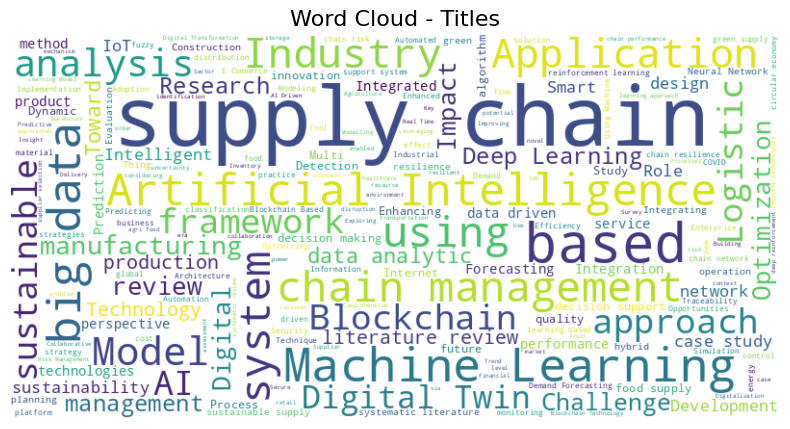

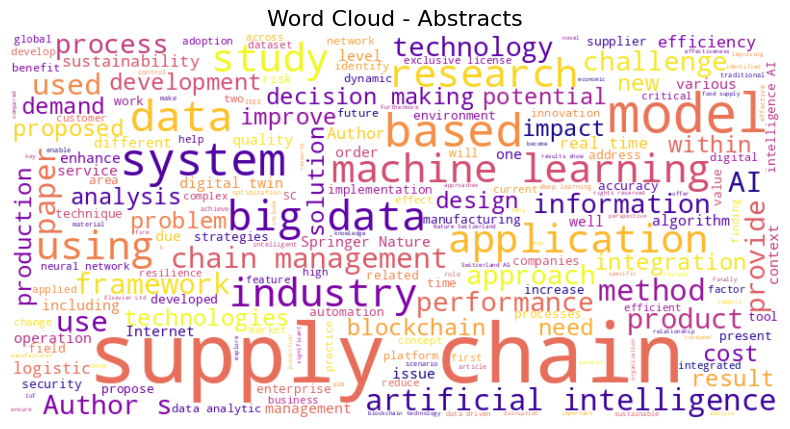

Berhasil membuat Word Cloud untuk Title dan Abstract.


In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

df['title'] = df['title'].fillna('').astype(str)
df['abstract'] = df['abstract'].fillna('').astype(str)

# 2. Gabungkan seluruh teks
all_titles = ' '.join(df['title'])
all_abstracts = ' '.join(df['abstract'])

# Setup Stopwords (kata umum yang akan diabaikan, misal: 'the', 'and', 'in')
stopwords = set(STOPWORDS)
# Jika ingin menambahkan kata yang mau dibuang:
# stopwords.update(['using', 'study', 'based', 'result'])

# --- GAMBAR 1: WORD CLOUD UNTUK TITLE ---
wc_title = WordCloud(width=800, height=400, 
                     background_color='white', 
                     stopwords=stopwords, 
                     colormap='viridis',  # Pilihan warna
                     max_words=200).generate(all_titles)

plt.figure(figsize=(10, 5))
plt.imshow(wc_title, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Titles', fontsize=16)
plt.savefig('title_wordcloud.png', bbox_inches='tight')
plt.show() # Tampilkan di notebook

# --- GAMBAR 2: WORD CLOUD UNTUK ABSTRACT ---
wc_abstract = WordCloud(width=800, height=400, 
                        background_color='white', 
                        stopwords=stopwords, 
                        colormap='plasma', # Pilihan warna beda
                        max_words=200).generate(all_abstracts)

plt.figure(figsize=(10, 5))
plt.imshow(wc_abstract, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Abstracts', fontsize=16)
plt.savefig('abstract_wordcloud.png', bbox_inches='tight')
plt.show() # Tampilkan di notebook

print("Berhasil membuat Word Cloud untuk Title dan Abstract.")

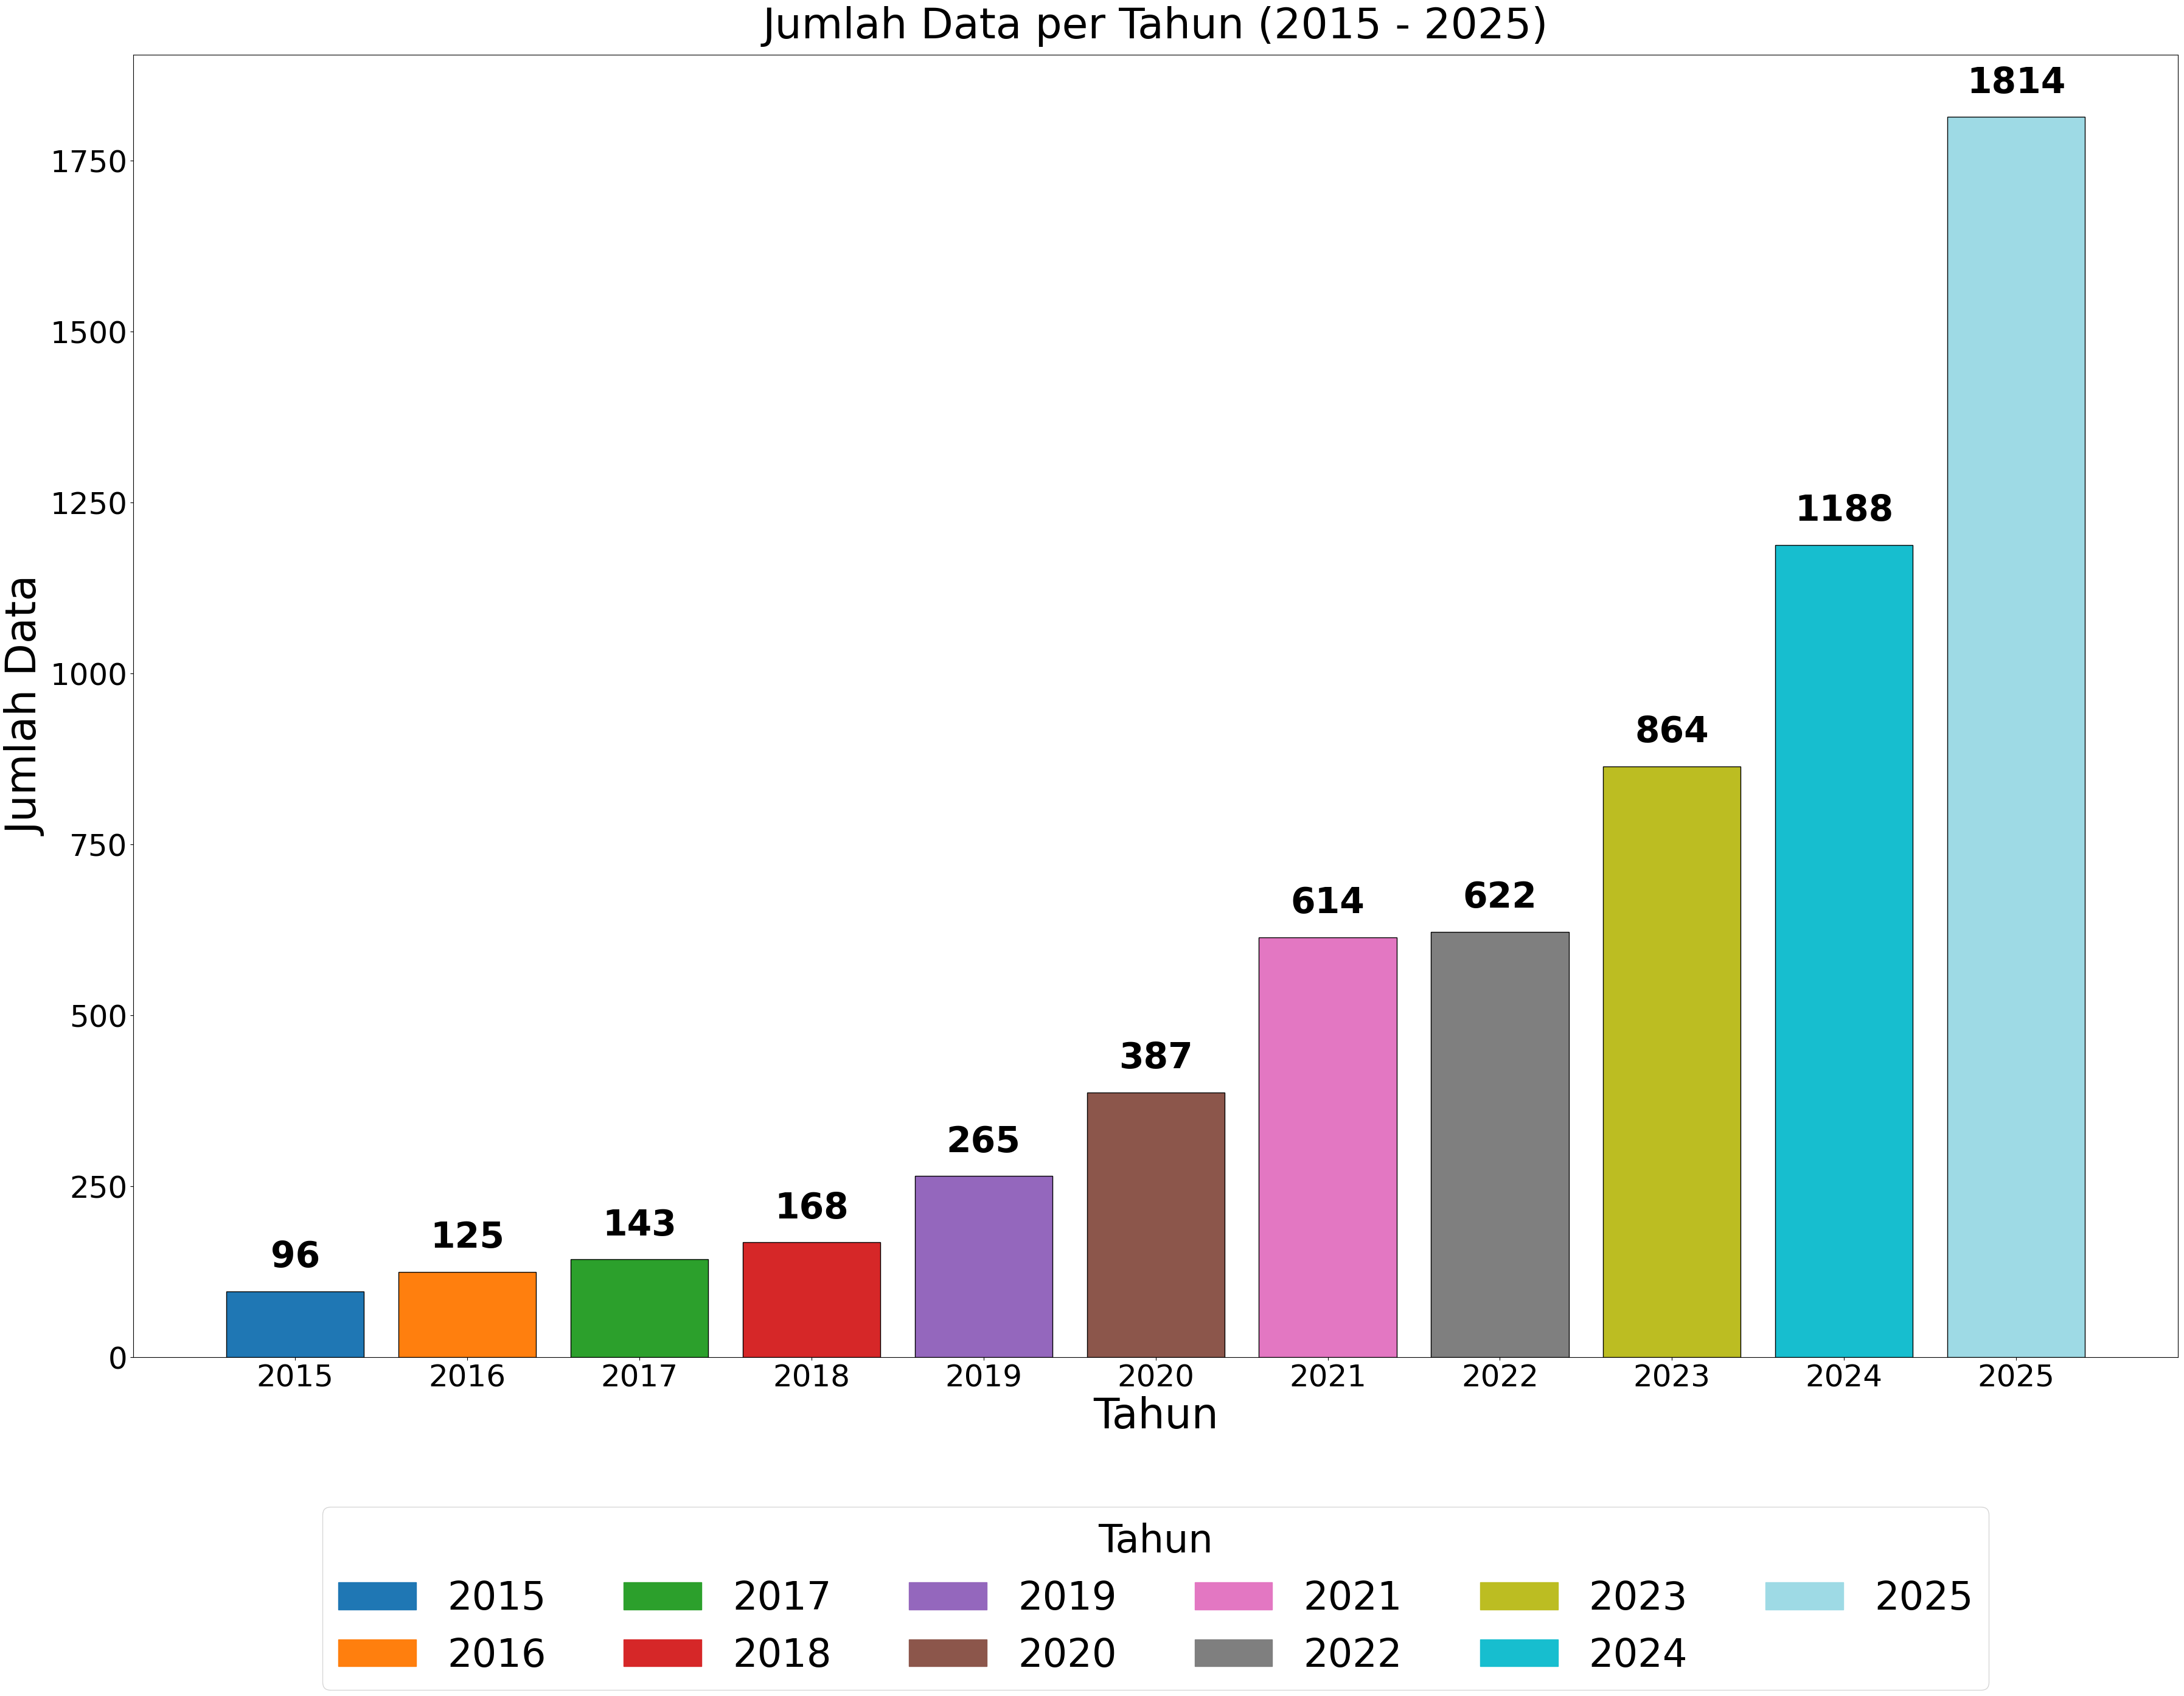

In [58]:
import numpy as np
import matplotlib.pyplot as plt 
year_counts = df['year'].value_counts().sort_index()
years = year_counts.index
counts = year_counts.values

# Atur ukuran plot lebih besar
plt.figure(figsize=(36, 28))

# Warna berbeda untuk tiap tahun
colors = plt.cm.tab20(np.linspace(0, 1, len(years)))

# Plot batang
bars = plt.bar(years, counts, color=colors, edgecolor='black')

# Judul dan Label dengan font lebih besar
plt.title('Jumlah Data per Tahun (2015 - 2025)', fontsize=50, pad=20)
plt.xlabel('Tahun', fontsize=50)
plt.ylabel('Jumlah Data', fontsize=50)

# Memastikan semua tahun (termasuk 2015) muncul di sumbu X
plt.xticks(years, fontsize=36)
plt.yticks(fontsize=36)

# Menambahkan angka di atas batang
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 25, f'{height}', 
             ha='center', va='bottom', fontsize=42, fontweight='bold')

# Legenda di bawah
# --- BAGIAN YANG DIUBAH (LEGENDA 2 BARIS) ---
handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(years))]

# ncol=6 artinya maksimal 6 item ke samping, sisanya turun ke bawah (jadi 2 baris)
# bbox_to_anchor y-nya diturunkan sedikit (-0.15) agar tidak menabrak label sumbu X
plt.legend(handles, years, loc='upper center', bbox_to_anchor=(0.5, -0.10), 
           ncol=6, title="Tahun", fontsize=46, title_fontsize=46)
# ---------------------------------------------
plt.tight_layout()
plt.savefig('data_per_tahun_large_legend.png', bbox_inches='tight')
plt.show()

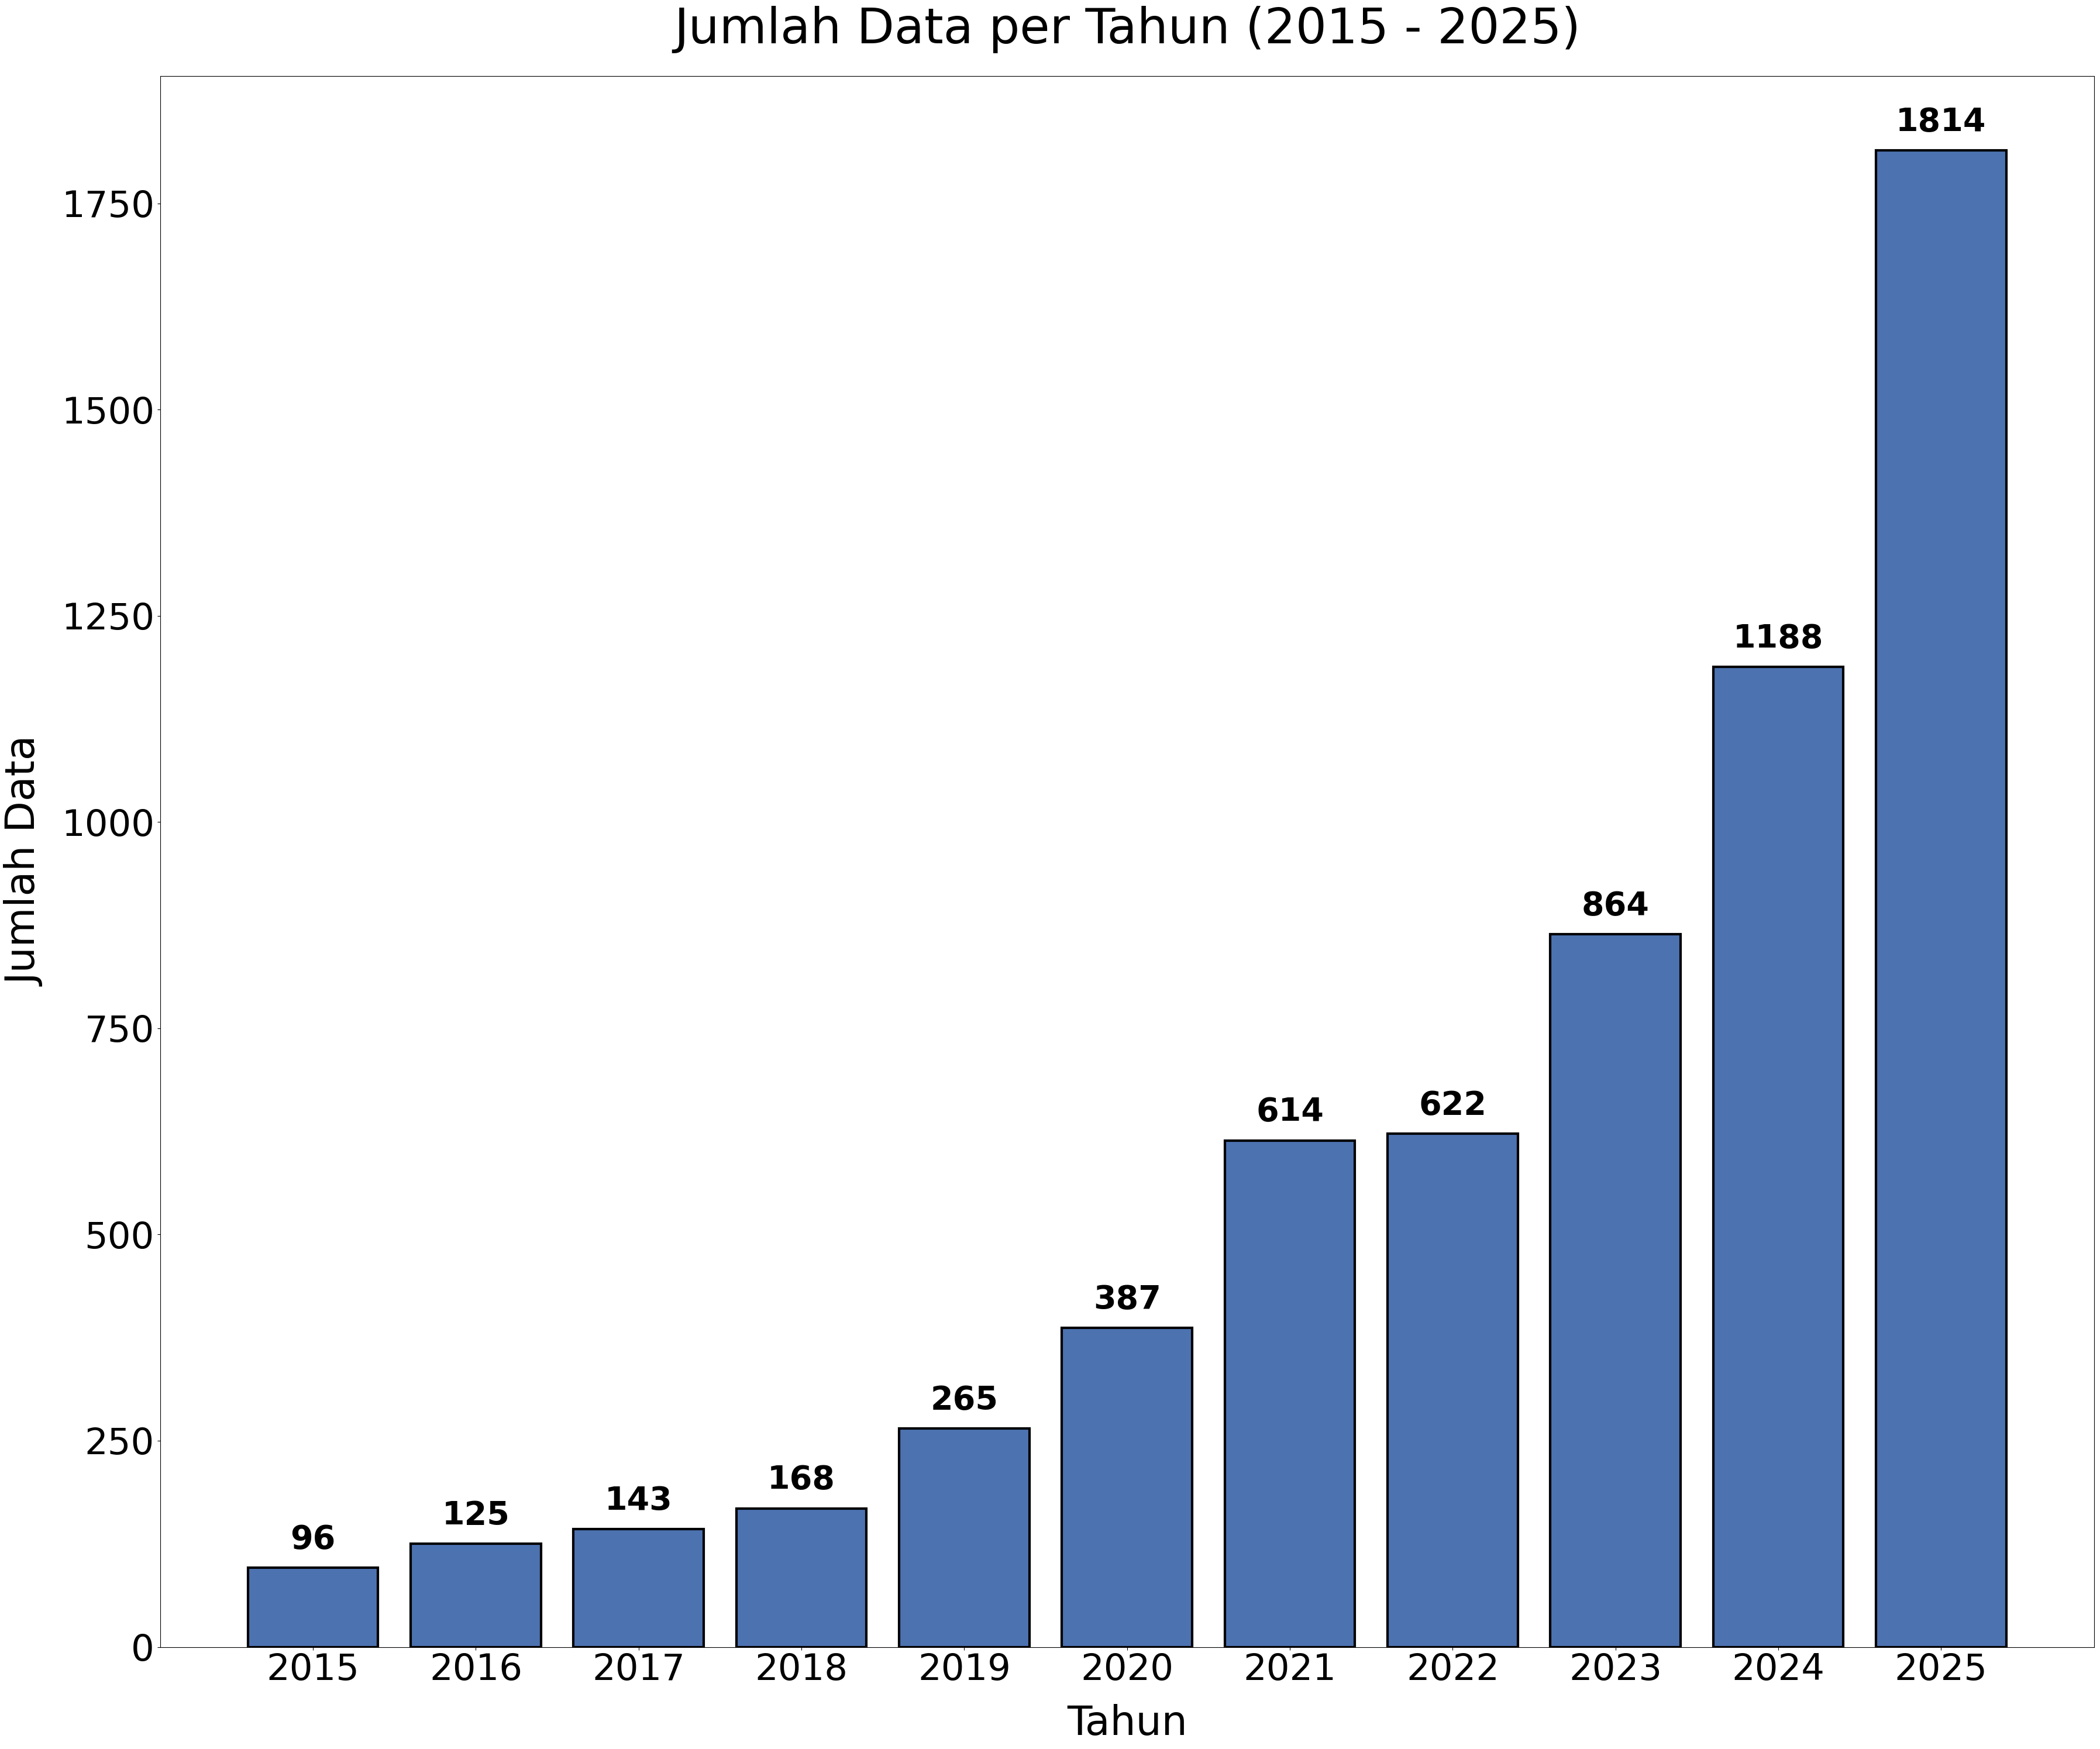

In [59]:
import numpy as np
import matplotlib.pyplot as plt 

# Pastikan df sudah terdefinisi sebelumnya
year_counts = df['year'].value_counts().sort_index()
years = year_counts.index
counts = year_counts.values

# Atur ukuran plot
plt.figure(figsize=(36, 30))

# --- PERUBAHAN UTAMA: Satu Warna Saja ---
# Saya gunakan warna biru standar yang rapi, dan sedikit pertebal garis pinggirnya
single_color = '#4C72B0'  # Anda bisa ganti dengan 'steelblue', 'skyblue', dll.
bars = plt.bar(years, counts, color=single_color, edgecolor='black', linewidth=3)

# Judul dan Label (Ukuran besar dipertahankan)
plt.title('Jumlah Data per Tahun (2015 - 2025)', fontsize=60, pad=40)
plt.xlabel('Tahun', fontsize=50, labelpad=20)
plt.ylabel('Jumlah Data', fontsize=50, labelpad=20)

# Ticks
plt.xticks(years, fontsize=45)
plt.yticks(fontsize=45)

# Menambahkan angka di atas batang
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 15, f'{height}', 
             ha='center', va='bottom', fontsize=40, fontweight='bold')

# --- PERUBAHAN KEDUA: Hapus bagian Legenda ---
# Bagian handles = ... dan plt.legend(...) dihapus total.
# ---------------------------------------------

plt.tight_layout()
# Simpan dengan nama file baru
plt.savefig('data_per_tahun_single_color.png', bbox_inches='tight')
plt.show()

In [60]:
# Fungsi untuk mengklasifikasikan Jurnal vs Conference berdasarkan Source Title
def classify_source(title):
    if not isinstance(title, str):
        return "Unknown"
    title_lower = title.lower()
    
    # Kata kunci umum untuk Conference / Proceedings
    conf_keywords = [
        'conference', 'proceedings', 'symposium', 'workshop', 'congress', 
        'convention', 'procedia', 'lecture notes', 'ifip', 'ifac', 
        'advances in', 'communications in', 'studies in'
    ]
    
    # Jika mengandung kata kunci conference, tandai sebagai Conference
    if any(kw in title_lower for kw in conf_keywords):
        return "Conference"
    
    # Sisanya diasumsikan sebagai Jurnal (termasuk IEEE Access, Sustainability, dll.)
    return "Journal"

# Terapkan klasifikasi
df['Document_Type'] = df['source_title'].apply(classify_source)

# Hitung jumlahnya
counts = df['Document_Type'].value_counts()
print(counts)

Document_Type
Journal       4394
Conference    1892
Name: count, dtype: int64


In [13]:
df.to_json('data_bersih.json', orient='records', indent=4, force_ascii=False)

print("Berhasil menyimpan data ke 'data_bersih.json'")

Berhasil menyimpan data ke 'data_bersih.json'
